# 08. Consolidación de Resultados: Híbrido vs Líneas Base

**Objetivo:** consolidar tablas comparativas, matrices de confusión, gráficos y ablaciones para el manuscrito.
**Entradas:** `data/*_eval.csv` (líneas base) y `data/outputs/train_<run_id>/*` generado por 07.
**Salidas:** `data/outputs/results_<run_id>/tabla_comparativa_modelos.csv`, `figures/*.png`, `indice_matrices_confusion.csv`, `resumen_resultados.json`.
**Notebook anterior:** `notebooks/pipeline/04a_linea_base_dummy.ipynb`, `04b_linea_base_tfidf.ipynb`, `04c_linea_base_transformers.ipynb`, `07_entrenamiento_modelos_hibridos.ipynb`.
**Notebook siguiente:** `notebooks/analysis/09_analisis_errores_hibrido.ipynb`.

> **Contrato de comparabilidad:** este notebook solo mantiene en la tabla final modelos evaluados sobre el mismo split denoised y el mismo `n_eval` del híbrido.


## Técnicas, herramientas y librerías de esta etapa

- **Técnica principal:** consolidación de métricas, tablas comparativas y visualización de resultados comparables en `dev`.
- **Herramientas/librerías:** `pandas`, `numpy`, `matplotlib`, métricas de `scikit-learn`.
- **Por qué es adecuada aquí:** esta etapa no crea modelos nuevos; ordena evidencia comparable entre líneas base e híbridos y evita conclusiones apoyadas solo en una tabla dispersa.
- **Limitación:** no reemplaza el cierre formal multicriterio de `09b` ni la lectura clínica de errores en `09`.
- **Alternativa posible:** librerías de visualización más ricas como `seaborn` o `plotly` serían válidas, pero el cuello de botella no es estético sino metodológico.


## Criterio de comparabilidad metodológica (08)

Este notebook consolida resultados **solo si son metodológicamente comparables** con el híbrido entrenado en 07.

Reglas de comparabilidad aplicadas:
- mismo `eval_split` del híbrido (`dev` o `test`);
- mismo `n_eval` esperado para ese split denoised;
- exclusión explícita de líneas base fuera de contrato.

Además, se preserva trazabilidad por `run_id` para enlazar tablas, matrices de confusión y predicciones por fila.


In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, balanced_accuracy_score

from utils_shared import setup_paths, ensure_dir

paths = setup_paths()
DATA_PATH = paths['DATA_PATH']
OUTPUTS_PATH = paths['OUTPUTS_PATH']

# Selección de corrida de entrenamiento (última por defecto)
TRAIN_RUN_ID = os.getenv('RESULTS_TRAIN_RUN_ID') or None
if TRAIN_RUN_ID is None:
    cand = sorted([p for p in OUTPUTS_PATH.glob('train_*') if p.is_dir()], key=lambda p: p.stat().st_mtime)
    if not cand:
        raise FileNotFoundError('No se encontraron carpetas train_* en data/outputs')
    TRAIN_RUN_ID = cand[-1].name

TRAIN_DIR = OUTPUTS_PATH / TRAIN_RUN_ID
print('TRAIN_DIR:', TRAIN_DIR)

RESULTS_RUN_ID = os.getenv('RESULTS_RUN_ID') or pd.Timestamp.now().strftime('results_%Y%m%d_%H%M%S')
RESULTS_DIR = ensure_dir(OUTPUTS_PATH / RESULTS_RUN_ID)
FIG_DIR = ensure_dir(RESULTS_DIR / 'figures')
print('RESULTS_DIR:', RESULTS_DIR)


TRAIN_DIR: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/train_20260310_093418
RESULTS_DIR: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/results_20260310_095135


In [2]:
# Cargar métricas de líneas base
baseline_files = {
    'dummy': DATA_PATH / 'dummy_eval.csv',
    'tfidf': DATA_PATH / 'tfidf_eval.csv',
    'beto': DATA_PATH / 'beto_eval.csv',
    'roberta_biomedical': DATA_PATH / 'roberta_biomedical_eval.csv',
    'roberta_clinical': DATA_PATH / 'roberta_clinical_eval.csv',
}

baseline_rows = []
for nombre, fpath in baseline_files.items():
    if not fpath.exists():
        continue
    df = pd.read_csv(fpath)
    if df.empty:
        continue
    row = df.iloc[0].to_dict()
    row['source'] = 'baseline_texto'
    row['profile'] = 'texto'
    row['model'] = str(row.get('modelo', nombre)).upper()
    baseline_rows.append(row)

baseline_df = pd.DataFrame(baseline_rows)
print('Baselines cargados:', len(baseline_df))


Baselines cargados: 5


In [3]:
# Cargar métricas híbridas
# Estas métricas provienen de artefactos exportados por el notebook 07.

cand_h = sorted(TRAIN_DIR.glob('comparacion_modelos_*.csv'), key=lambda p: p.stat().st_mtime)
if not cand_h:
    raise FileNotFoundError(f'No se encontró comparacion_modelos_*.csv en {TRAIN_DIR}')

hybrid_path = cand_h[-1]
hybrid_df = pd.read_csv(hybrid_path)
hybrid_df['source'] = 'hibrido'

train_meta = {}
train_meta_path = TRAIN_DIR / 'resumen_entrenamiento.json'
if train_meta_path.exists():
    try:
        train_meta = json.loads(train_meta_path.read_text(encoding='utf-8'))
    except Exception as e:
        print('Aviso: no se pudo leer resumen_entrenamiento.json:', e)

# Normalización de nombres
rename_map = {
    'f1': 'f1_macro',
    'macro_f1': 'f1_macro',
    'macro_f1_score': 'f1_macro',
    'balanced_accuracy': 'balanced_acc',
    'modelo': 'model',
}
baseline_df = baseline_df.rename(columns=rename_map)
hybrid_df = hybrid_df.rename(columns=rename_map)

# Evitar ambigüedad por columnas duplicadas (ej. modelo/model)
baseline_df = baseline_df.loc[:, ~baseline_df.columns.duplicated()].copy()
hybrid_df = hybrid_df.loc[:, ~hybrid_df.columns.duplicated()].copy()

for df in (baseline_df, hybrid_df):
    if 'model' in df.columns:
        df['model'] = df['model'].astype(str).str.upper()


# Backbone contextual y metadatos de trazabilidad
if 'text_backbone' not in hybrid_df.columns:
    hybrid_df['text_backbone'] = train_meta.get('feature_text_backbone', np.nan)
if 'context_prefixes' not in hybrid_df.columns:
    pref = train_meta.get('feature_context_prefixes', [])
    if isinstance(pref, list):
        pref = '|'.join(pref)
    hybrid_df['context_prefixes'] = pref if pref else np.nan
if 'contexto_activo' not in hybrid_df.columns:
    hybrid_df['contexto_activo'] = train_meta.get('train_use_context', train_meta.get('train_use_beto', np.nan))

if 'text_backbone' not in baseline_df.columns:
    baseline_df['text_backbone'] = np.nan
if 'context_prefixes' not in baseline_df.columns:
    baseline_df['context_prefixes'] = np.nan
if 'contexto_activo' not in baseline_df.columns:
    baseline_df['contexto_activo'] = np.nan

if 'model' in baseline_df.columns:
    m = baseline_df['model'].astype(str).str.upper()
    baseline_df.loc[m.eq('BETO'), 'text_backbone'] = 'beto'
    baseline_df.loc[m.eq('ROBERTA_CLINICAL'), 'text_backbone'] = 'roberta_clinical'
    baseline_df.loc[m.eq('ROBERTA_BIOMEDICAL'), 'text_backbone'] = 'roberta_biomedical'


# Consolidar tamaño de evaluación baseline sin perder información de columnas legacy
if 'n_eval' not in baseline_df.columns:
    baseline_df['n_eval'] = np.nan
for aux_col in ['n_dev', 'n_test']:
    if aux_col in baseline_df.columns:
        mask_aux = baseline_df['n_eval'].isna() & baseline_df[aux_col].notna()
        baseline_df.loc[mask_aux, 'n_eval'] = baseline_df.loc[mask_aux, aux_col]


# Completar métricas híbridas desde predicciones exportadas por 07
for col in ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy', 'balanced_acc', 'n_eval', 'eval_split']:
    if col not in hybrid_df.columns:
        hybrid_df[col] = np.nan

for idx, row in hybrid_df.iterrows():
    profile = str(row.get('profile', '')).strip().lower()
    model = str(row.get('model', '')).strip().lower()
    split = str(row.get('eval_split', 'dev')).strip().lower()
    if split in {'', 'nan', 'none'}:
        split = 'dev'

    pred_path = TRAIN_DIR / f'predicciones_{profile}_{model}_{split}.csv'
    if not pred_path.exists():
        continue

    dfp = pd.read_csv(pred_path)
    if not {'y_true', 'y_pred'}.issubset(dfp.columns):
        continue

    y_true = dfp['y_true'].astype(str)
    y_pred = dfp['y_pred'].astype(str)

    m = {
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
        'n_eval': len(dfp),
        'eval_split': split,
    }

    for col, val in m.items():
        if pd.isna(hybrid_df.at[idx, col]):
            hybrid_df.at[idx, col] = val

# Definir contrato esperado desde el híbrido
expected_split = None
if 'eval_split' in hybrid_df.columns and hybrid_df['eval_split'].notna().any():
    expected_split = str(hybrid_df['eval_split'].dropna().astype(str).mode().iloc[0]).lower()
if expected_split in {'', 'nan', 'none', None}:
    expected_split = str(train_meta.get('eval_on', 'dev')).strip().lower() or 'dev'

expected_n_eval = np.nan
expected_path = paths['SPLITS_PATH'] / f'{expected_split}_denoised.csv'
if expected_path.exists():
    try:
        expected_n_eval = len(pd.read_csv(expected_path))
    except Exception:
        pass

print('Contrato esperado -> split:', expected_split, '| n_eval:', expected_n_eval)

# Completar métricas baseline para evitar NaN no informativos
for col in ['balanced_acc', 'n_eval', 'eval_split', 'cv_macro_f1']:
    if col not in baseline_df.columns:
        baseline_df[col] = np.nan

# En este problema, balanced accuracy equivale al promedio de recall por clase
if {'balanced_acc', 'recall_macro'}.issubset(baseline_df.columns):
    msk_ba = baseline_df['balanced_acc'].isna() & baseline_df['recall_macro'].notna()
    baseline_df.loc[msk_ba, 'balanced_acc'] = baseline_df.loc[msk_ba, 'recall_macro']

baseline_df['eval_split'] = baseline_df['eval_split'].fillna(expected_split)
baseline_df['n_eval'] = pd.to_numeric(baseline_df['n_eval'], errors='coerce')
if not pd.isna(expected_n_eval):
    baseline_df['n_eval'] = baseline_df['n_eval'].fillna(float(expected_n_eval))

# Filtrar baselines que no cumplen el contrato de comparabilidad
if not baseline_df.empty:
    m_split = baseline_df['eval_split'].astype(str).str.lower() == expected_split
    if pd.isna(expected_n_eval):
        m_n = pd.Series([True] * len(baseline_df), index=baseline_df.index)
    else:
        m_n = baseline_df['n_eval'].astype(float) == float(expected_n_eval)

    comparable_mask = m_split & m_n
    dropped = baseline_df.loc[~comparable_mask, ['model', 'eval_split', 'n_eval']].copy()
    if not dropped.empty:
        print('Aviso: se excluyen baselines no comparables con el contrato del híbrido:')
        print(dropped.to_string(index=False))

    baseline_df = baseline_df.loc[comparable_mask].copy()

# Marcar explícitamente disponibilidad de CV
baseline_df['cv_macro_f1'] = baseline_df['cv_macro_f1'].fillna('no_aplica')
hybrid_df['cv_macro_f1'] = hybrid_df['cv_macro_f1'].fillna('no_disponible')

if 'model' in hybrid_df.columns:
    modelos_h = set(hybrid_df['model'].dropna().astype(str).str.upper().unique())
    if 'RF' not in modelos_h:
        print('Aviso: no se encontraron filas RF en comparacion_modelos_*.csv')
    if train_meta.get('use_xgb', True) and 'XGB' not in modelos_h:
        print('Aviso: se esperaba XGB pero no se encontraron filas XGB en comparacion_modelos_*.csv')

# Armar tabla consolidada para comparación principal
cols_keep = [
    'source', 'profile', 'model', 'text_backbone', 'context_prefixes', 'contexto_activo',
    'f1_macro', 'balanced_acc', 'precision_macro', 'recall_macro',
    'accuracy', 'cv_macro_f1', 'n_train', 'n_eval', 'eval_split'
]

def keep_available(df):
    return df[[c for c in cols_keep if c in df.columns]].copy()

frames = []
if not baseline_df.empty:
    frames.append(keep_available(baseline_df))
if not hybrid_df.empty:
    frames.append(keep_available(hybrid_df))

if not frames:
    raise ValueError('No hay métricas disponibles para consolidar.')

consolidado = pd.concat(frames, ignore_index=True)
consolidado_path = RESULTS_DIR / 'tabla_comparativa_modelos.csv'
consolidado.to_csv(consolidado_path, index=False)
print('Guardado:', consolidado_path)

display(consolidado.sort_values('f1_macro', ascending=False))


Contrato esperado -> split: dev | n_eval: 343
Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/results_20260310_095135/tabla_comparativa_modelos.csv


,source,profile,model,f1_macro,balanced_acc,precision_macro,recall_macro,accuracy,cv_macro_f1,n_train,n_eval,eval_split
4,baseline_texto,texto,ROBERTA_CLINICAL,0.741078,0.763889,0.732286,0.763889,0.769679,no_aplica,1107,343,dev
1,baseline_texto,texto,TFIDF,0.740564,0.767716,0.732290,0.767716,0.766764,no_aplica,1107,343,dev
3,baseline_texto,texto,ROBERTA_BIOMEDICAL,0.725490,0.732407,0.720347,0.732407,0.766764,no_aplica,1107,343,dev
2,baseline_texto,texto,BETO,0.705194,0.734198,0.700246,0.734198,0.731778,no_aplica,1107,343,dev
8,hibrido,py,XGB,0.688997,0.684753,0.694418,0.684753,0.749271,no_disponible,1107,343,dev
6,hibrido,core,XGB,0.681765,0.677695,0.686991,0.677695,0.743440,no_disponible,1107,343,dev
5,hibrido,core,RF,0.677252,0.687716,0.671808,0.687716,0.720117,0.656522,1107,343,dev
7,hibrido,py,RF,0.673086,0.682716,0.667915,0.682716,0.717201,0.659403,1107,343,dev
0,baseline_texto,texto,DUMMY,0.494237,0.494506,0.494766,0.494506,0.571429,no_aplica,1107,343,dev


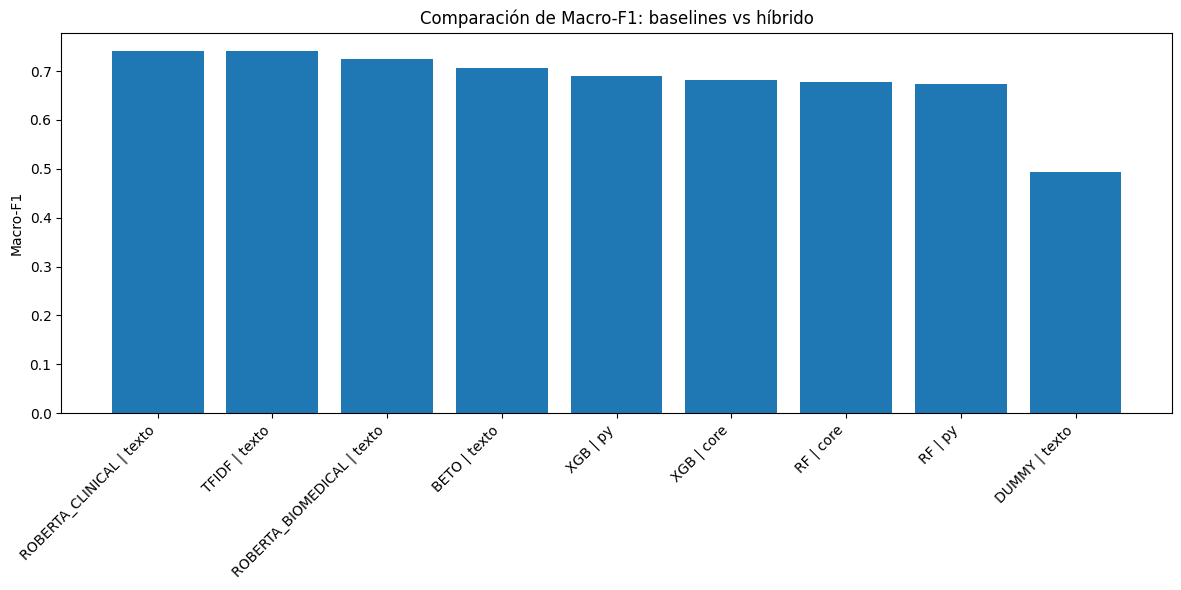

Figura: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/results_20260310_095135/figures/comparacion_macro_f1.png


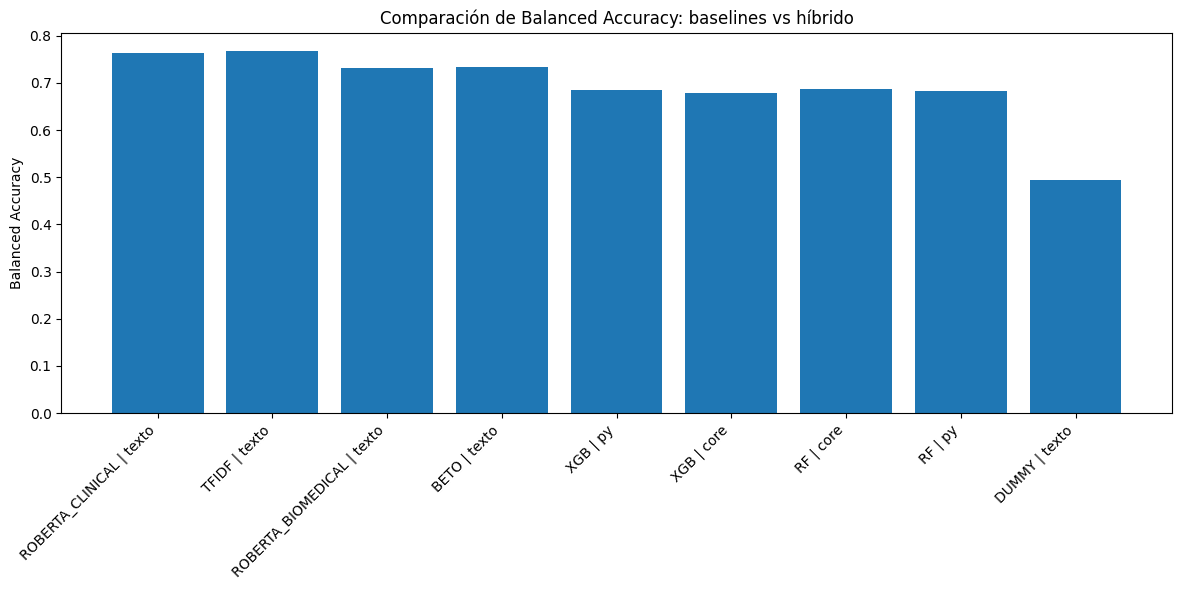

Figura: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/results_20260310_095135/figures/comparacion_balanced_accuracy.png


In [4]:
# Gráfico de Macro-F1
plot_df = consolidado.dropna(subset=['f1_macro']).copy()
if plot_df.empty:
    print('Aviso: No hay filas con f1_macro para graficar.')
else:
    plot_df['etiqueta_modelo'] = plot_df['model'] + ' | ' + plot_df['profile'].astype(str)
    plot_df = plot_df.sort_values('f1_macro', ascending=False)

    plt.figure(figsize=(12, 6))
    plt.bar(plot_df['etiqueta_modelo'], plot_df['f1_macro'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Macro-F1')
    plt.title('Comparación de Macro-F1: baselines vs híbrido')
    plt.tight_layout()
    fig_f1 = FIG_DIR / 'comparacion_macro_f1.png'
    plt.savefig(fig_f1, dpi=200)
    plt.show()
    print('Figura:', fig_f1)

    # Gráfico de Balanced Accuracy
    if 'balanced_acc' in plot_df.columns:
        bdf = plot_df.dropna(subset=['balanced_acc']).copy()
        if not bdf.empty:
            plt.figure(figsize=(12, 6))
            plt.bar(bdf['etiqueta_modelo'], bdf['balanced_acc'])
            plt.xticks(rotation=45, ha='right')
            plt.ylabel('Balanced Accuracy')
            plt.title('Comparación de Balanced Accuracy: baselines vs híbrido')
            plt.tight_layout()
            fig_ba = FIG_DIR / 'comparacion_balanced_accuracy.png'
            plt.savefig(fig_ba, dpi=200)
            plt.show()
            print('Figura:', fig_ba)


In [5]:
# Ablación core vs py (solo híbrido)
if not hybrid_df.empty and {'profile', 'model', 'f1_macro'}.issubset(hybrid_df.columns):
    abl = hybrid_df.pivot_table(index='model', columns='profile', values='f1_macro', aggfunc='mean').reset_index()
    if {'core', 'py'}.issubset(set(abl.columns)):
        abl['delta_py_vs_core'] = abl['py'] - abl['core']
    abl_path = RESULTS_DIR / 'ablacion_core_vs_py.csv'
    abl.to_csv(abl_path, index=False)
    print('Guardado:', abl_path)
    display(abl)


Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/results_20260310_095135/ablacion_core_vs_py.csv


profile,model,core,py,delta_py_vs_core
0,RF,0.677252,0.673086,-0.004166
1,XGB,0.681765,0.688997,0.007233


In [6]:
# Matrices de confusión desde predicciones exportadas por 07
pred_files = sorted(TRAIN_DIR.glob('predicciones_*_*.csv'))
cm_rows = []

for p in pred_files:
    dfp = pd.read_csv(p)
    if not {'y_true', 'y_pred'}.issubset(dfp.columns):
        continue

    labels = sorted(pd.Series(list(set(dfp['y_true']) | set(dfp['y_pred']))).astype(str).unique())
    cm = confusion_matrix(dfp['y_true'].astype(str), dfp['y_pred'].astype(str), labels=labels)
    cmn = confusion_matrix(dfp['y_true'].astype(str), dfp['y_pred'].astype(str), labels=labels, normalize='true')

    base = p.stem
    cm_csv = RESULTS_DIR / f'{base}_matriz_confusion.csv'
    pd.DataFrame(cm, index=labels, columns=labels).to_csv(cm_csv)

    plt.figure(figsize=(7, 6))
    plt.imshow(cmn)
    plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
    plt.yticks(range(len(labels)), labels)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title(f'Matriz de confusión normalizada | {base}')
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    cm_fig = FIG_DIR / f'{base}_matriz_confusion.png'
    plt.savefig(cm_fig, dpi=200)
    plt.close()

    cm_rows.append({'archivo_predicciones': p.name, 'matriz_csv': cm_csv.name, 'figura': cm_fig.name})

cm_index = pd.DataFrame(cm_rows)
cm_index_path = RESULTS_DIR / 'indice_matrices_confusion.csv'
cm_index.to_csv(cm_index_path, index=False)
print('Guardado:', cm_index_path)


Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/results_20260310_095135/indice_matrices_confusion.csv


In [7]:
# Resumen de ejecución final para manuscrito
resumen = {}
if not consolidado.empty and 'f1_macro' in consolidado.columns:
    top = consolidado.sort_values('f1_macro', ascending=False).iloc[0].to_dict()
    resumen['mejor_modelo'] = top

resumen['train_run_id_origen'] = TRAIN_RUN_ID
resumen['results_run_id'] = RESULTS_RUN_ID
resumen['comparacion_hibrida_origen'] = hybrid_path.name


# Selección Transformer de 04c para trazabilidad
sel_latest = OUTPUTS_PATH / 'transformer_baseline_selection_latest.json'
if sel_latest.exists():
    try:
        sel_payload = json.loads(sel_latest.read_text(encoding='utf-8'))
        resumen['transformer_baseline_selection_path'] = str(sel_latest)
        resumen['transformer_baseline_seleccionado_04c'] = (sel_payload.get('mejor_transformer_baseline', {}) or {}).get('modelo')
    except Exception as e:
        print('Aviso: no se pudo leer selección Transformer latest:', e)

if not baseline_df.empty and 'model' in baseline_df.columns:
    trf = baseline_df[baseline_df['model'].astype(str).str.upper().isin(['BETO', 'ROBERTA_CLINICAL', 'ROBERTA_BIOMEDICAL'])].copy()
    if not trf.empty:
        trf_top = trf.sort_values('f1_macro', ascending=False).iloc[0].to_dict()
        resumen['mejor_transformer_baseline_en_tabla'] = trf_top

resumen_path = RESULTS_DIR / 'resumen_resultados.json'
with open(resumen_path, 'w', encoding='utf-8') as f:
    json.dump(resumen, f, ensure_ascii=False, indent=2)

print('Resumen:', resumen_path)
print('Consolidación finalizada.')


Resumen: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/results_20260310_095135/resumen_resultados.json
Consolidación finalizada.


## Lectura interpretativa mínima para validación clínica

La tabla comparativa no debe leerse solo como ranking:

- `TF-IDF` funciona como baseline léxico-estadístico fuerte y parsimonioso;
- `ROBERTA_CLINICAL` resume el mejor baseline contextual standalone en `dev`;
- el híbrido final no se selecciona por ganar en métrica pura, sino por combinar señal contextual con trazabilidad clínica y reglas reutilizables.

La comparación clínica más curada entre estos enfoques, incluyendo solapamiento de aciertos y casos exclusivos, se centraliza en `10_validacion_clinica_ips.ipynb`.
